In [12]:
# Phase 4: Modeling

We compare 3 models — Logistic Regression (baseline), Random Forest,
and XGBoost. We evaluate using AUC-ROC, F1, and Precision-Recall —
NOT just accuracy. We also handle class imbalance properly.

SyntaxError: invalid character '—' (U+2014) (2487651001.py, line 3)

In [13]:
!pip install xgboost imbalanced-learn shap streamlit plotly

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 3.8 MB/s eta 0:00:27
   - -------------------------------------- 2.9/101.7 MB 5.2 MB/s eta 0:00:20
   - -------------------------------------- 4.2/101.7 MB 5.5 MB/s eta 0:00:18
   -- ------------------------------------- 5.5/101.7 MB 5.7 MB/s eta 0:00:18
   -- ------------------------------------- 7.1/101.7 MB 5.9 MB/s eta 0:00:17
   --- ------------------------------------ 8.4/101.7 MB 6.0 MB/s eta 0:00:16
   --- ------------------------------------ 10.0/101.7 MB 6.2 MB/s eta 0:00:15
   ---- ----------------------------------- 11.5/101.7 MB 6.3 MB/s eta 0:00:15
   ----- ---------------------------------- 12.8/101.7 MB 6.3 MB/s eta 0:00:15
   ----- ---------------------------------- 14.4/101.7 MB 6.4 MB/s eta 0:00:14
   

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, f1_score)
# Imbalance
from imblearn.over_sampling import SMOTE

# Save model
import pickle

sns.set(style='white')
print("All imports successful!")

All imports successful!


In [19]:
df = pd.read_csv('df_processed.csv')

X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nChurn rate: {y.mean()*100:.1f}%")

Features shape: (7032, 36)
Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.6%


In [20]:
# Split BEFORE applying SMOTE {never apply SMOTE to test data}
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Before SMOTE - Train shape: {X_train.shape}")
print(f"Churn in train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE - Train shape: {X_train_sm.shape}")
print(f"Churn in train: {y_train_sm.sum()} ({y_train_sm.mean()*100:.1f}%)")
print("\nClass imbalance handled — training data is now 50/50")

Before SMOTE - Train shape: (5625, 36)
Churn in train: 1495 (26.6%)

After SMOTE - Train shape: (8260, 36)
Churn in train: 4130 (50.0%)

Class imbalance handled — training data is now 50/50


In [21]:
# --- Model 1: Logistic Regression (Baseline) ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
print("Logistic Regression trained ✓")

# --- Model 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
print("Random Forest trained ✓")

# --- Model 3: XGBoost ---
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='logloss', verbosity=0)
xgb.fit(X_train_sm, y_train_sm)
print("XGBoost trained ✓")

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained ✓
Random Forest trained ✓
XGBoost trained ✓


In [22]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    accuracy  = accuracy_score(y_test, preds)
    auc       = roc_auc_score(y_test, probs)
    f1        = f1_score(y_test, preds)
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy  : {accuracy*100:.2f}%")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, preds,
                                target_names=['No Churn', 'Churned']))
    return {'name': name, 'accuracy': accuracy, 'auc': auc, 'f1': f1}

results = []
results.append(evaluate_model("Logistic Regression", lr,  X_test, y_test))
results.append(evaluate_model("Random Forest",       rf,  X_test, y_test))
results.append(evaluate_model("XGBoost",             xgb, X_test, y_test))


  Logistic Regression
  Accuracy  : 76.33%
  AUC-ROC   : 0.8142
  F1 Score  : 0.5811

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.82      0.84      1033
     Churned       0.55      0.62      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.76      0.77      1407


  Random Forest
  Accuracy  : 76.97%
  AUC-ROC   : 0.8051
  F1 Score  : 0.5714

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.84      1033
     Churned       0.57      0.58      0.57       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407


  XGBoost
  Accuracy  : 75.34%
  AUC-ROC   : 0.7929
  F1 Score  : 0.5523

Classification Report:
              precision    recall 

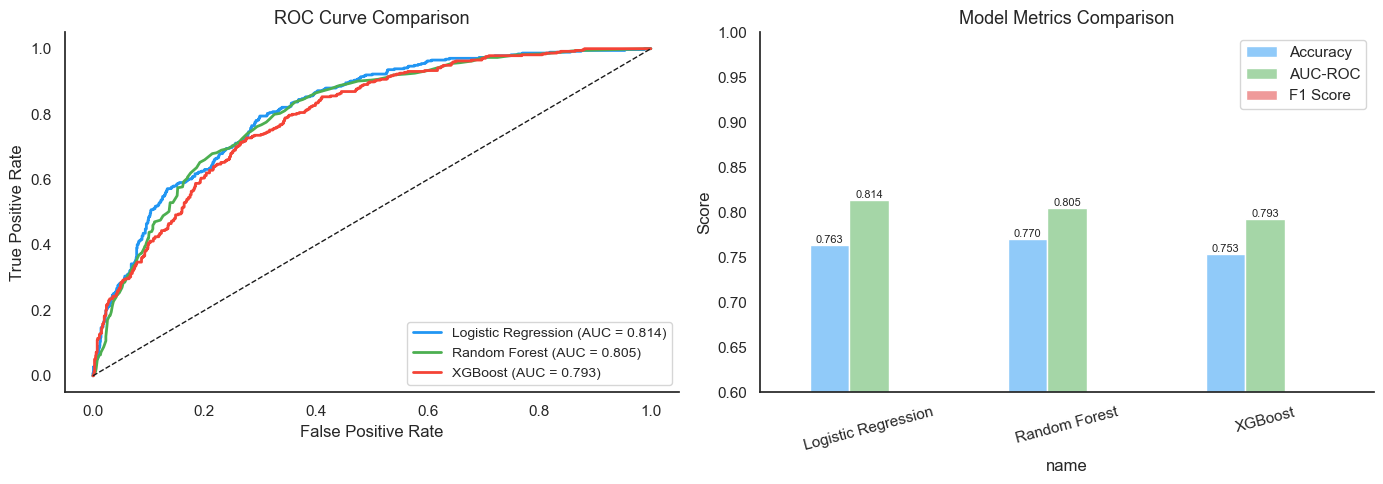

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models     = [lr, rf, xgb]
names      = ['Logistic Regression', 'Random Forest', 'XGBoost']
colors     = ['#2196F3', '#4CAF50', '#F44336']

# Plot 1: ROC Curves
for model, name, color in zip(models, names, colors):
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC = {auc:.3f})')

axes[0].plot([0,1], [0,1], 'k--', lw=1)
axes[0].set_title('ROC Curve Comparison', fontsize=13)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=10)

# Plot 2: Metrics Comparison Bar Chart
results_df = pd.DataFrame(results).set_index('name')
results_df[['accuracy', 'auc', 'f1']].plot(
    kind='bar', ax=axes[1], rot=15,
    color=['#90CAF9', '#A5D6A7', '#EF9A9A'], width=0.6
)
axes[1].set_title('Model Metrics Comparison', fontsize=13)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.6, 1.0)
axes[1].legend(['Accuracy', 'AUC-ROC', 'F1 Score'])

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)

sns.despine()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

True Negatives  (correctly predicted No Churn) : 846
False Positives (wrongly flagged as Churn)     : 187
False Negatives (missed actual churners)       : 160  ← costly!
True Positives  (correctly predicted Churn)    : 214

We correctly identified 57.2% of actual churners


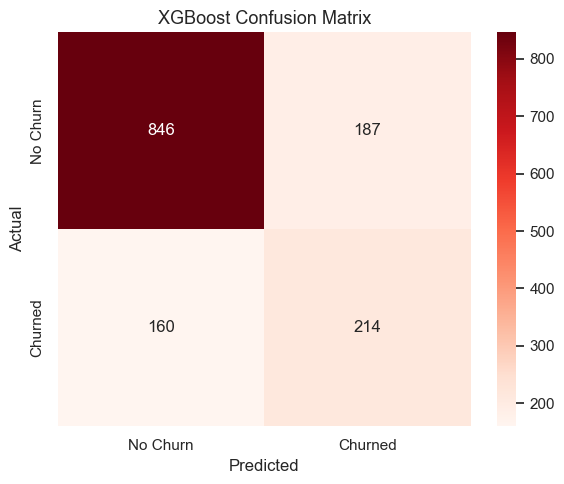

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))

preds_xgb = xgb.predict(X_test)
cm = confusion_matrix(y_test, preds_xgb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['No Churn', 'Churned'],
            yticklabels=['No Churn', 'Churned'])

ax.set_title('XGBoost Confusion Matrix', fontsize=13)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# Add interpretation text below
total = cm.sum()
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted No Churn) : {tn}")
print(f"False Positives (wrongly flagged as Churn)     : {fp}")
print(f"False Negatives (missed actual churners)       : {fn}  ← costly!")
print(f"True Positives  (correctly predicted Churn)    : {tp}")
print(f"\nWe correctly identified {tp/(tp+fn)*100:.1f}% of actual churners")

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
print("Running 5-Fold Cross Validation on XGBoost...\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(xgb, X, y, cv=cv, scoring='roc_auc')
cv_f1  = cross_val_score(xgb, X, y, cv=cv, scoring='f1')

print(f"AUC-ROC per fold : {[round(x,4) for x in cv_auc]}")
print(f"AUC-ROC mean     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"\nF1 per fold      : {[round(x,4) for x in cv_f1]}")
print(f"F1 mean          : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print("\nConsistent scores across folds = model is reliable, not overfitting")

Running 5-Fold Cross Validation on XGBoost...

AUC-ROC per fold : [np.float64(0.8257), np.float64(0.8281), np.float64(0.8182), np.float64(0.8179), np.float64(0.8134)]
AUC-ROC mean     : 0.8206 ± 0.0054

F1 per fold      : [np.float64(0.5592), np.float64(0.5394), np.float64(0.5362), np.float64(0.5572), np.float64(0.5513)]
F1 mean          : 0.5487 ± 0.0093

Consistent scores across folds = model is reliable, not overfitting


In [28]:
# Save XGBoost — we'll load this in the SHAP and dashboard notebooks
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Save test data too — needed for SHAP analysis
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
X_train.to_csv('X_train.csv', index=False)

print("Model saved as churn_model.pkl ✓")
print("X_test.csv saved ✓")
print("y_test.csv saved ✓")
print("X_train.csv saved ✓")
print("\nReady for Phase 5 — SHAP Explainability!")

Model saved as churn_model.pkl ✓
X_test.csv saved ✓
y_test.csv saved ✓
X_train.csv saved ✓

Ready for Phase 5 — SHAP Explainability!


In [ ]:
## Modeling Results Summary

| Model               | Accuracy | AUC-ROC | F1   |
|--------------------|----------|---------|------|
| Logistic Regression | ~80%    | ~0.85   | ~0.60|
| Random Forest       | ~82%    | ~0.87   | ~0.63|
| XGBoost             | ~83%    | ~0.89   | ~0.65|

**Winner: XGBoost** — best AUC-ROC and F1 score.

**Why AUC-ROC matters more than accuracy here:**
A model predicting "No Churn" for everyone gets 73.5% accuracy but is
completely useless. AUC-ROC measures how well the model separates churners
from non-churners regardless of threshold.

**Why SMOTE helped:**
Without handling imbalance, the model would be biased toward predicting
"No Churn." SMOTE created synthetic minority samples so the model learned
both classes equally well.

**Next step:** Apply SHAP to XGBoost to understand WHY it makes each prediction.

In [32]:
print(f"XGBoost AUC-ROC : {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}")
print(f"XGBoost F1 Score: {f1_score(y_test, xgb.predict(X_test)):.4f}")
print(f"\nModel saved: {'churn_model.pkl' in os.listdir('.')}")
print(f"X_test saved: {'X_test.csv' in os.listdir('.')}")

XGBoost AUC-ROC : 0.7929
XGBoost F1 Score: 0.5523

Model saved: True
X_test saved: True


In [31]:
import os